In [1]:
import sys
from pathlib import Path

# add project root to python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("Added to path:", PROJECT_ROOT)

Added to path: /Users/hussam/Desktop/Folders/salik_optimizer


In [2]:
import osmnx as ox

place = "Dubai, United Arab Emirates"

G = ox.graph_from_place(place, network_type="drive")

ox.save_graphml(G, "../data/dubai.graphml")

In [3]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent   # move out of notebooks folder
csv_path = BASE_DIR / "data" / "salik_gates.csv"

print(csv_path)  # sanity check

gates = pd.read_csv(csv_path)
gates

/Users/hussam/Desktop/Folders/salik_optimizer/data/salik_gates.csv


,name,lat,lon,radius_m
0,Al Barsha,25.116861,55.192619,60
1,Al Safa South,25.178158,55.247000,60
2,Al Safa North,25.193916,55.261795,60
3,Al Garhoud Bridge,25.231067,55.335624,60
4,Al Maktoum Bridge,25.252680,55.321312,60
5,Airport Tunnel,25.249193,55.387272,60
6,Jebel Ali,25.028213,55.101182,60
7,Business Bay Crossing,25.224797,55.341225,60
8,Al Mamzar North,25.297061,55.361356,60
9,Al Mamzar South,25.286387,55.359017,60


In [4]:
def meters_to_degrees(meters):
    return meters / 111_000

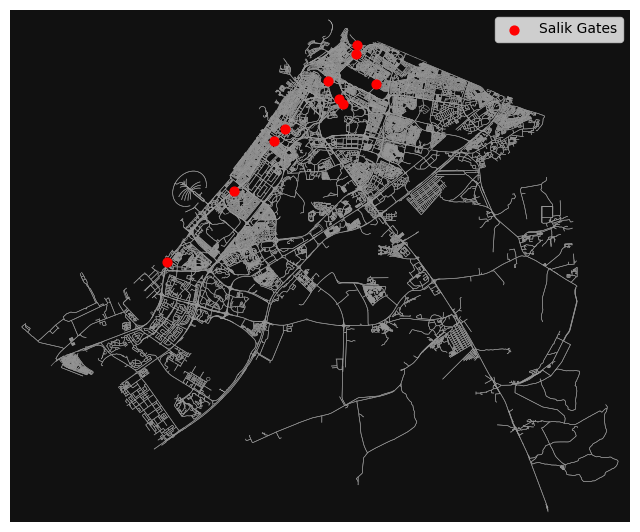

In [5]:
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd

# load graph
G = ox.load_graphml("../data/dubai.graphml")

# load gates
gates = pd.read_csv("../data/salik_gates.csv")

# plot roads
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.4,
                        show=False, close=False)

# plot gates
ax.scatter(gates["lon"], gates["lat"],
           c="red", s=40, label="Salik Gates")

plt.legend()
plt.show()

In [6]:
from shapely.geometry import Point

# create geometric points
gates["geometry"] = gates.apply(
    lambda row: Point(row["lon"], row["lat"]),
    axis=1
)

gates.head()

,name,lat,lon,radius_m,geometry
0,Al Barsha,25.116861,55.192619,60,POINT (55.19261855365215 25.116860636355195)
1,Al Safa South,25.178158,55.247000,60,POINT (55.246999792261335 25.178158203837633)
2,Al Safa North,25.193916,55.261795,60,POINT (55.26179543275771 25.19391580186546)
3,Al Garhoud Bridge,25.231067,55.335624,60,POINT (55.33562441952024 25.231067241121274)
4,Al Maktoum Bridge,25.252680,55.321312,60,POINT (55.321311602173495 25.252679709484884)


In [7]:
from geopy.distance import geodesic

def is_near_gate(lat, lon, gates_df):
    for _, gate in gates_df.iterrows():
        dist = geodesic(
            (lat, lon),
            (gate["lat"], gate["lon"])
        ).meters

        if dist <= gate["radius_m"]:
            return True, gate["name"]

    return False, None

In [8]:
test_lat = 25.23
test_lon = 55.33

is_near_gate(test_lat, test_lon, gates)

(False, None)

In [9]:
test_lat = 25.231067
test_lon = 55.335624

is_near_gate(test_lat, test_lon, gates)

(True, 'Al Garhoud Bridge')

In [10]:
from src.routing import shortest_route
from src.toll_detector import route_tolls
from src.cost_model import compute_route_cost

In [11]:
from src.routing import shortest_route, k_routes
from src.toll_detector import route_tolls
from src.cost_model import compute_route_cost

In [12]:
import osmnx as ox
from pathlib import Path

BASE_DIR = Path.cwd().parent
graph_path = BASE_DIR / "data" / "dubai.graphml"

G = ox.load_graphml(graph_path)

print("Graph loaded:", len(G.nodes), "nodes")

Graph loaded: 61251 nodes


In [13]:
import osmnx as ox

origin = ox.distance.nearest_nodes(G, 55.27, 25.20)
destination = ox.distance.nearest_nodes(G, 55.35, 25.28)

route = shortest_route(G, origin, destination)

len(route)

120

In [14]:
tolls = route_tolls(route, G, gates)
tolls

[]

In [15]:
route_length = sum(
    ox.routing.route_to_gdf(G, route)["length"]
)

route_length

14408.766678356229

In [16]:
compute_route_cost(route_length, tolls)

{'time_cost': 7204.3833391781145,
 'toll_cost': 0,
 'total_cost': 7204.3833391781145}

In [17]:
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

from src.routing import apply_synthetic_travel_time
G = apply_synthetic_travel_time(G, scenario="road_class")

In [ ]:
from src.routing import generate_candidate_routes

routes = generate_candidate_routes(G, origin, destination)

print("Generated routes:", len(routes))

In [ ]:
from src.routing import route_travel_time

results = []

for r in routes:

    # count tolls
    tolls = route_tolls(r, G, gates)

    # FAST travel time calculation (already optimized)
    travel_time = route_travel_time(G, r)   # minutes

    # compute generalized cost
    cost = compute_route_cost(travel_time, tolls)

    results.append((r, cost))

NameError: name 'routes' is not defined

In [ ]:
best_route = min(results, key=lambda x: x[1]["total_cost"])

In [ ]:
for i, r in enumerate(routes):
    print(f"Route {i+1} nodes:", len(r))

Route 1 nodes: 120
Route 2 nodes: 114
Route 3 nodes: 121
Route 4 nodes: 121
Route 5 nodes: 115


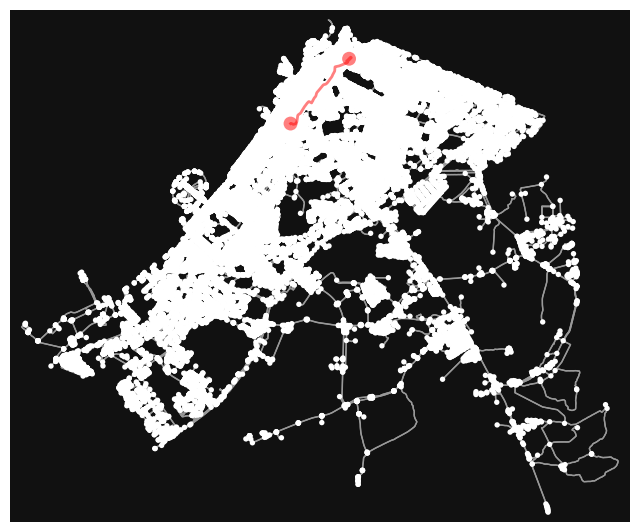

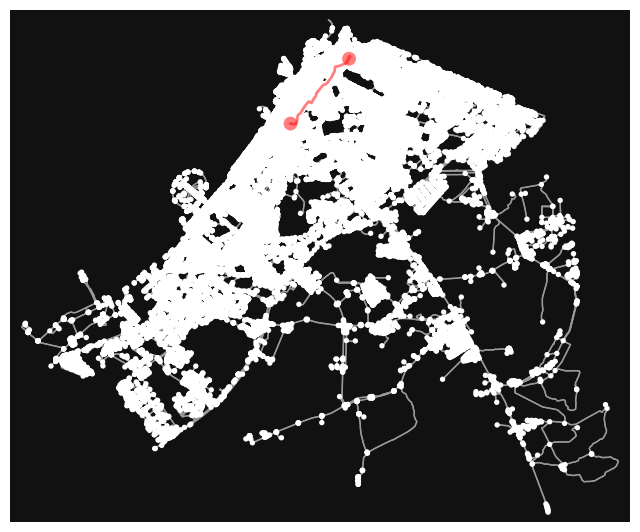

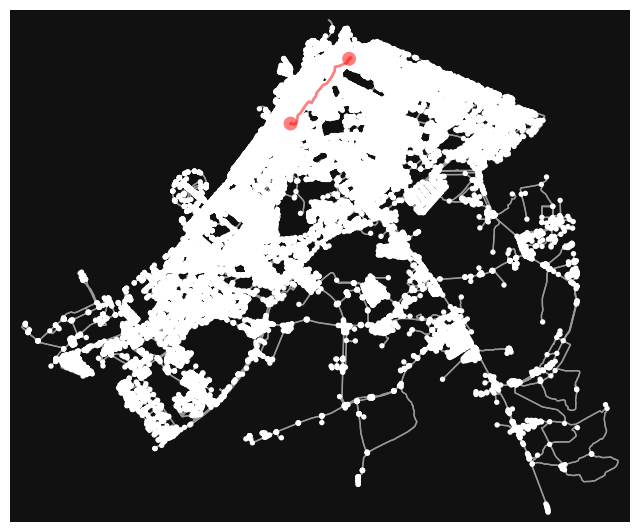

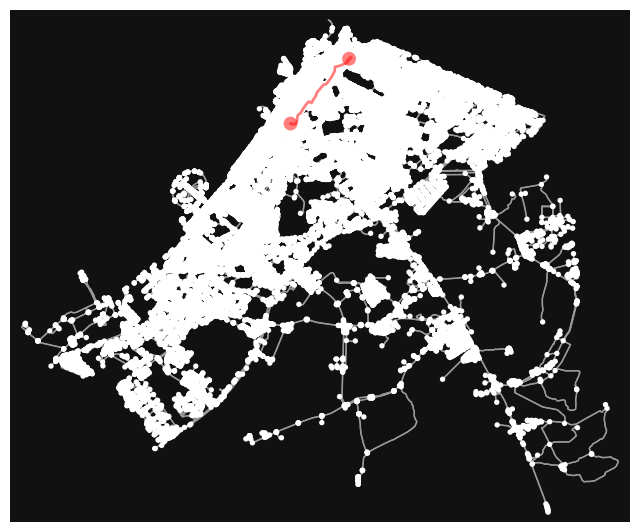

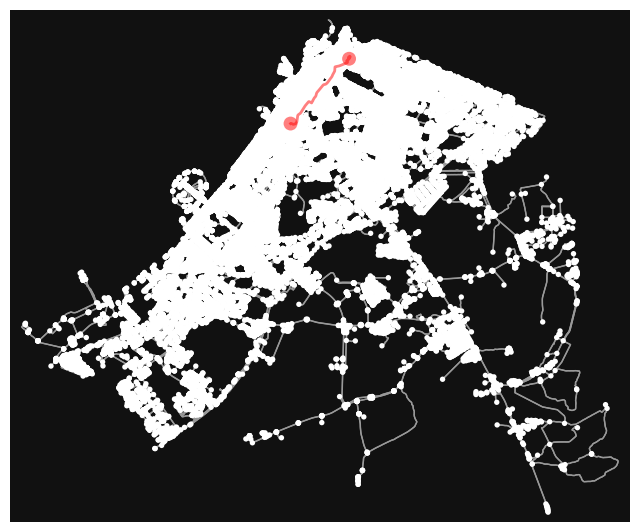

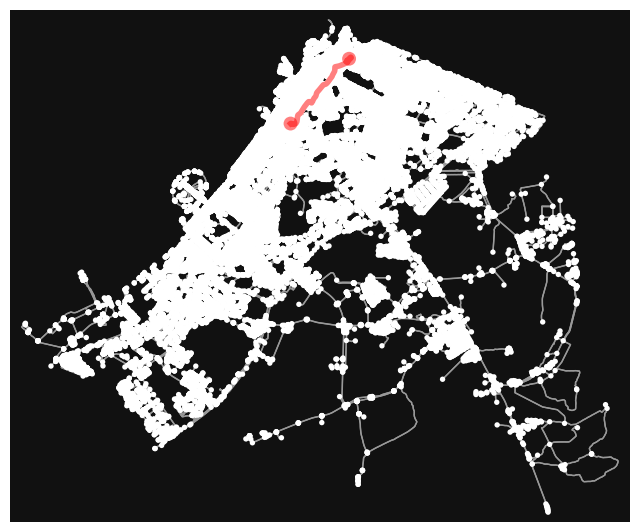

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import matplotlib.pyplot as plt

for r, cost in results:
    ox.plot_graph_route(G, r, route_linewidth=2, show=False, close=False)

ox.plot_graph_route(G, best_route[0], route_color="red", route_linewidth=4)

In [ ]:
routeA = {
    "time": 32,
    "toll": 0
}

routeB = {
    "time": 24,
    "toll": 8
}

In [ ]:
from src.analysis import find_switch_point

switch_value = find_switch_point(routeA, routeB)

print("Switch occurs at:", switch_value, "AED per minute")

Switch occurs at: 1.0 AED per minute


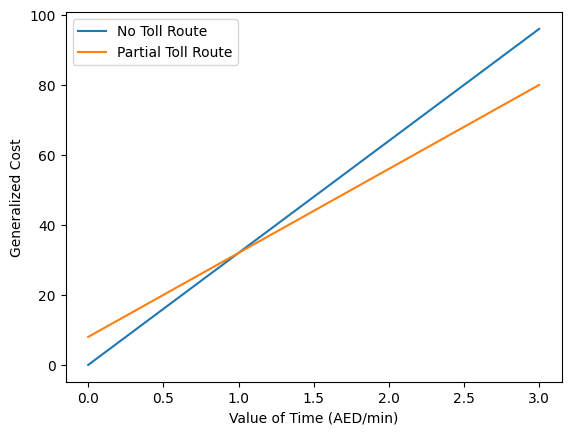

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.analysis import compute_generalized_cost

values = np.linspace(0, 3, 50)

costA = [
    compute_generalized_cost(routeA["time"], routeA["toll"], v)
    for v in values
]

costB = [
    compute_generalized_cost(routeB["time"], routeB["toll"], v)
    for v in values
]

plt.figure()
plt.plot(values, costA, label="No Toll Route")
plt.plot(values, costB, label="Partial Toll Route")

plt.xlabel("Value of Time (AED/min)")
plt.ylabel("Generalized Cost")
plt.legend()
plt.show()

In [ ]:
import osmnx as ox

G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

In [ ]:
results = []

for r in routes:
    tolls = route_tolls(r, G, gates)
    travel_time = route_travel_time(G, r)
    cost = compute_route_cost(travel_time, tolls)
    results.append((r, cost))

In [ ]:
best_route = min(results, key=lambda x: x[1]["total_cost"])

print(best_route[1])

{'time_cost': 7.159228442877098, 'toll_cost': 0, 'total_cost': 7.159228442877098}


In [ ]:
for i, (route, cost) in enumerate(results):
    print(
        f"Route {i+1}: "
        f"time_cost={cost['time_cost']:.2f}, "
        f"tolls={cost['toll_cost']:.2f}, "
        f"total={cost['total_cost']:.2f}"
    )

Route 1: time_cost=7.20, tolls=0.00, total=7.20
Route 2: time_cost=7.16, tolls=0.00, total=7.16
Route 3: time_cost=7.25, tolls=0.00, total=7.25
Route 4: time_cost=7.22, tolls=0.00, total=7.22
Route 5: time_cost=7.21, tolls=0.00, total=7.21
